In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from glob import glob
from PIL import Image
import pandas as pd
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops
from tensorflow.keras.utils import load_img, img_to_array
from skimage.morphology import remove_small_objects, remove_small_holes, binary_closing, disk

In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_d2a760e9c0b21e8e5d2147e657f460d7"

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('umud-challenge-muscle-architecture-in-ultrasound-data')

print("Path to competition files:", path)

100%|██████████| 2.56G/2.56G [00:25<00:00, 108MB/s] 

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/umud-challenge-muscle-architecture-in-ultrasound-data


In [ ]:
base = "/root/.cache/kagglehub/competitions/umud-challenge-muscle-architecture-in-ultrasound-data"

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving apo_model_dice.keras to apo_model_dice.keras
Saving fascicle_model.keras to fascicle_model.keras


In [ ]:
# Dice coefficient measures how much the predicted mask overlaps with the true mask
# Higher Dice is better, with 1 meaning perfect overlap
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Flatten the masks so we compare all pixels together
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    # Count the overlapping pixels between the true and predicted masks
    intersection = tf.reduce_sum(y_true * y_pred)

    # Compute Dice score
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

# Dice loss is the opposite of Dice score
# Lower Dice loss means better segmentation
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

# Combine binary crossentropy and Dice loss
# BCE helps with pixel-wise classification
# Dice helps with mask overlap
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)

    return bce + dice

In [ ]:
apo_model_dice = tf.keras.models.load_model(
    "/content/apo_model_dice.keras",
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coef": dice_coef
    }
)

fas_model_dice = tf.keras.models.load_model(
    "/content/fascicle_model.keras",
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coef": dice_coef
    }
)

In [ ]:
test_images = sorted(
    glob("/root/.cache/kagglehub/competitions/umud-challenge-muscle-architecture-in-ultrasound-data/test_images_v2/test_set_v2/*")
)

In [ ]:
competition_dir = "/root/.cache/kagglehub/competitions/umud-challenge-muscle-architecture-in-ultrasound-data"

In [ ]:
def collect_metadata(pattern):
    """Determine px_per_cm and the bounding box for every image whose path matches pattern."""
    old_a = None
    nt = []
    test_df = []
    prev_dist_list = []
    for path in sorted(glob(f'{competition_dir}/{pattern}')):
        px_per_cm = -1
        l, t, r, b = -1, -1, -1, -1
        id = int(path[-8:-4])
        filetype = path[-3:]
        with Image.open(path) as img:
            a = np.asarray(img)
        if len(a.shape) == 3:
            assert a.shape[2] == 3
        height, width = a.shape[:2]

        # Determine the scale (pixels per cm)
        if filetype == 'png':
            # only in test dataset
            # variable scale (3..6 cm high)
            # images are 2.85 cm wide and have square pixels
            first_tick = np.argmax(a[:, 6].mean(axis=-1) > 50) # 117
            second_minor_tick = 150 + np.argmax(a[150:, 6].mean(axis=-1) > 50)
            second_major_tick = 150 + np.argmax(a[150:, 9].mean(axis=-1) > 50)
            last_tick = len(a) - 1 - np.argmax(a[:, 6].mean(axis=-1)[::-1] > 50)
            if (second_major_tick - first_tick) < 3 * (second_minor_tick - first_tick):
                px_per_cm = second_major_tick - first_tick # major ticks are 10 mm, minor ticks are 5 mm
            else:
                px_per_cm = second_minor_tick - first_tick # major ticks are 50 mm, minor ticks are 10 mm
            hw = a.shape[1] // 2
            w2 = np.argmin(a[:, hw:].sum(axis=(0, 2)))
            l, t, r, b = hw - w2, first_tick, hw + w2, last_tick
            assert 2.8 < (r - l) / px_per_cm < 2.9 # image width in cm
        elif a.shape == (800, 1200, 3):
            # tick marks can be left, right, and at the bottom; train images can be hflipped; pixels can be non-square
            if (a[87, 1147:1157] == 175).all():
                # variable scale (3..7 cm high), tick marks at right border
                # images in test dataset are 5.75 cm wide and have square pixels
                assert (a[87, 1147:1157] == 175).all() # first tick
                first_tick = np.argmax(a[:, 1150].mean(axis=-1) > 50) # 87
                # assert first_tick == 87, first_tick
                second_major_tick = first_tick + 20 + np.argmax(a[first_tick + 20:, 1150].mean(axis=-1) > 50)
                last_tick = len(a) - 1 - np.argmax(a[:, 1150].mean(axis=-1)[::-1] > 50)
                n_ticks = (last_tick - first_tick) / (second_major_tick - first_tick)
                nt.append(n_ticks)
                n_ticks = round(n_ticks)
                if n_ticks <= 14:
                    px_per_cm = (last_tick - first_tick) / n_ticks * 2 # <= 14 ticks -> 2 ticks per cm
                    if n_ticks == 7:
                        l, t, r, b = 142, 91, 1058, last_tick # 3.5 cm
                    elif n_ticks == 8:
                        l, t, r, b = 162, 91, 1038, last_tick # 4 cm
                    elif n_ticks == 9:
                        l, t, r, b = 210, 91, 990, last_tick # 4.5 cm
                    elif n_ticks == 10:
                        l, t, r, b = 249, 91, 951, last_tick # 5 cm
                    elif n_ticks == 11:
                        l, t, r, b = 281, 91, 919, last_tick # 5.5 cm
                    elif n_ticks == 12:
                        l, t, r, b = 307, 91, 893, last_tick # 6 cm
                    elif n_ticks == 13:
                        l, t, r, b = 330, 91, 870, last_tick # 6.5 cm
                    elif n_ticks == 14:
                        l, t, r, b = 349, 91, 851, last_tick # 7 cm
                    else:
                        assert False
                    assert 5.7 < (r - l) / px_per_cm < 5.8 # image width in cm
                elif n_ticks == 15:
                    px_per_cm = (last_tick - first_tick) / 3 # 15 ticks = 3 cm -> 5 ticks per cm
                    l, t, r, b = 142, 91, 1058, last_tick # 3 cm
                    assert 5.7 < (r - l) / px_per_cm < 5.8 # image width in cm
                else:
                    assert False
            elif  (a[42, 67:74, 0] > 115).all():
                # 42px = 0 cm, 783px = 5 cm, tick marks at left border
                px_per_cm = (783 - 42) / 5
                l, t, r, b = 170, 42, 1030, 798 # ticks left 5 cm
            else:
                assert False
        elif a.shape == (644, 1088, 3):
            # 0px = 0cm, 630.5px = 5 cm
            px_per_cm = 630.5 / 5
            l, t, r, b = 140, 0, 947, 643 # ticks left 5 cm
        elif a.shape[0] in [512, 513]:
            # fixed scale
            if a[-5, 49, 0] == 168 and a[-5, 438, 0] == 168:
                px_per_cm = (442 - 53) / 5
            elif a[-5, 52, 0] == 168 and a[-5, 441, 0] == 168:
                px_per_cm = (442 - 53) / 5
            elif a[-5, 53, 0] == 168 and a[-5, 442, 0] == 168:
                px_per_cm = (442 - 53) / 5
            else:
                assert False
            l, t, r, b = 0, 0, width, height - 10
        elif a.shape[0] == 853:
            assert len(a.shape) == 2
            if a[-5, 100] == 170 and a[-5, 934] == 170:
                px_per_cm = (934 - 100) / 5
            elif a[-5, 44] == 170 and a[-5, 879] == 170:
                px_per_cm = (879 - 44) / 5
            else:
                assert False
            l, t, r, b = 0, 0, width, height
        else:
            assert False, "Unknown format"

        test_df.append((id,
                        path.split('/')[-1],
                        filetype,
                        a.shape[0], a.shape[1],
                        len(a.shape),
                        px_per_cm,
                        l, t, r, b))
        # print(f"{id:4}.{filetype}: {a.shape[0]:5} {a.shape[1]:5} {len(a.shape)} {px_per_cm:7.2f}")

    test_df = pd.DataFrame(test_df, columns=['id', 'image_id', 'filetype', 'height', 'width', 'dim', 'px_per_cm', 'l', 't', 'r', 'b'])
    print(f'good: {((test_df.px_per_cm > 0) & (test_df.l >= 0)).mean():.0%}')
    return test_df

In [ ]:
test_df = collect_metadata('test_images_v2/test_set_v2/IMG_*.*') # 309 images
test_df.to_csv("test_df.csv", index=False)
test_df

good: 100%


,id,image_id,filetype,height,width,dim,px_per_cm,l,t,r,b
0,1,IMG_00001.tif,tif,800,1200,3,135.333333,210,91,990,696
1,2,IMG_00002.tif,tif,800,1200,3,152.250000,162,91,1038,696
2,3,IMG_00003.tif,tif,800,1200,3,135.333333,210,91,990,696
3,4,IMG_00004.tif,tif,800,1200,3,135.333333,210,91,990,696
4,5,IMG_00005.tif,tif,800,1200,3,101.500000,307,91,893,696
...,...,...,...,...,...,...,...,...,...,...,...
304,305,IMG_00305.png,png,800,1200,3,172.000000,354,117,846,722
305,306,IMG_00306.png,png,800,1200,3,172.000000,354,117,846,722
306,307,IMG_00307.png,png,800,1200,3,153.000000,381,117,819,734
307,308,IMG_00308.png,png,800,1200,3,150.000000,385,117,815,722


In [ ]:
IMG_SIZE = 512

In [ ]:
def clean_mask(mask, min_size=100, hole_size=100):
    # Make sure mask is boolean
    mask = mask.astype(bool)

    # Remove tiny disconnected blobs
    mask = remove_small_objects(mask, min_size=min_size)

    # Fill small holes inside predicted regions
    mask = remove_small_holes(mask, area_threshold=hole_size)

    # Smooth small gaps
    mask = binary_closing(mask, disk(2))

    return mask

In [ ]:
img_path = test_images[1]

print(img_path)

/root/.cache/kagglehub/competitions/umud-challenge-muscle-architecture-in-ultrasound-data/test_images_v2/test_set_v2/IMG_00002.tif


In [ ]:
IMG_SIZE = 512

img = load_img(
    img_path,
    color_mode="grayscale",
    target_size=(IMG_SIZE, IMG_SIZE)
)

img = img_to_array(img).astype("float32") / 255.0

img_batch = np.expand_dims(img, axis=0)

In [ ]:
apo_pred = apo_model_dice.predict(img_batch)
fas_pred = fas_model_dice.predict(img_batch)

apo_mask = (apo_pred[0, :, :, 0] > 0.5)
fas_mask = (fas_pred[0, :, :, 0] > 0.5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
apo_clean = clean_mask(apo_mask, min_size=350, hole_size=300)
fas_clean = clean_mask(fas_mask, min_size=50, hole_size=50)

In [ ]:
def fascicle_between_aponeuroses(points, top_curve, bottom_curve):
    if len(top_curve) == 0 or len(bottom_curve) == 0:
        return False

    inside = 0

    for y, x in points:
        top_idx = np.argmin(np.abs(top_curve[:, 0] - x))
        bottom_idx = np.argmin(np.abs(bottom_curve[:, 0] - x))

        top_y = top_curve[top_idx, 1]
        bottom_y = bottom_curve[bottom_idx, 1]

        if top_y <= y <= bottom_y:
            inside += 1

    return inside / len(points) > 0.8

In [ ]:
def remove_apo_from_fascicle_mask(fas_mask, top_curve, bottom_curve, margin=10):
    """
    Remove fascicle predictions close to the aponeuroses.
    margin is in resized 512x512 pixels.
    """

    if len(top_curve) == 0 or len(bottom_curve) == 0:
        return fas_mask

    cleaned = fas_mask.copy()
    h, w = cleaned.shape

    for x in range(w):
        top_y = curve_y_at_x(top_curve, x)
        bottom_y = curve_y_at_x(bottom_curve, x)

        if top_y is not None:
            y1 = max(0, int(top_y - margin))
            y2 = min(h, int(top_y + margin))
            cleaned[y1:y2, x] = False

        if bottom_y is not None:
            y1 = max(0, int(bottom_y - margin))
            y2 = min(h, int(bottom_y + margin))
            cleaned[y1:y2, x] = False

    return cleaned

In [ ]:
def extract_aponeurosis_curves(apo_clean, min_area=1300):
    height, width = apo_clean.shape

    labeled = label(apo_clean)
    regions = regionprops(labeled)

    # Remove tiny regions
    regions = [r for r in regions if r.area > min_area]

    if len(regions) < 2:
        return np.empty((0, 2)), np.empty((0, 2))

    # Sort regions from top to bottom
    regions = sorted(regions, key=lambda r: r.centroid[0])

    # If there are 3+ thick lines, the first one is probably skin
    if len(regions) >= 3:
        top_region = regions[1]      # superficial aponeurosis
        bottom_region = regions[-1]  # deep aponeurosis
    else:
        top_region = regions[0]      # superficial aponeurosis
        bottom_region = regions[1]   # deep aponeurosis

    top_mask = labeled == top_region.label
    bottom_mask = labeled == bottom_region.label

    top_curve = []
    bottom_curve = []

    for x in range(width):
        top_ys = np.where(top_mask[:, x])[0]
        bottom_ys = np.where(bottom_mask[:, x])[0]

        if len(top_ys) > 0:
            top_curve.append([x, np.max(top_ys)])

        if len(bottom_ys) > 0:
            bottom_curve.append([x, np.min(bottom_ys)])

    return np.array(top_curve).reshape(-1, 2), np.array(bottom_curve).reshape(-1, 2)

In [ ]:
# Compute MT in resized pixels
def compute_mt_pixels(top_curve, bottom_curve, img_size=512, x_positions=[0.25, 0.50, 0.75]):
    # Fallback if aponeurosis detection failed
    if len(top_curve) == 0 or len(bottom_curve) == 0:
        return None, None

    mt_values = []

    for frac in x_positions:
        x_target = int(frac * img_size)

        top_idx = np.argmin(np.abs(top_curve[:, 0] - x_target))
        bottom_idx = np.argmin(np.abs(bottom_curve[:, 0] - x_target))

        top_y = top_curve[top_idx, 1]
        bottom_y = bottom_curve[bottom_idx, 1]

        mt_px = abs(bottom_y - top_y)
        mt_values.append(mt_px)

    return mt_values, float(np.mean(mt_values))



# Convert resized pixels to millimeters using test_df metadata
def convert_resized_px_to_mm(px_value, row, resized_size=512):
    if px_value is None:
        return None

    original_height = row["b"] - row["t"]

    scale_y = original_height / resized_size
    original_px = px_value * scale_y

    mm_per_px = 10 / row["px_per_cm"]

    return original_px * mm_per_px


In [ ]:
def fit_line_to_points(points):
    points = np.asarray(points)

    if points.ndim != 2 or points.shape[0] < 2:
        return None, None

    y = points[:, 0]
    x = points[:, 1]

    if len(x) < 2 or np.all(x == x[0]):
        return None, None

    m, b = np.polyfit(x, y, 1)
    return m, b


def line_angle_degrees(m):
    # Convert slope to angle in degrees
    return np.degrees(np.arctan(m))


def angle_between_lines(m1, m2):
    # Angle between two slopes
    angle = np.degrees(np.arctan(abs((m1 - m2) / (1 + m1 * m2))))

    return angle

In [ ]:
def curve_y_at_x(curve, x):
    if curve is None or len(curve) == 0:
        return None

    curve = np.asarray(curve).reshape(-1, 2)

    idx = np.argmin(np.abs(curve[:, 0] - x))
    return curve[idx, 1]

In [ ]:
def predict_image(idx, show=False):
    """
    Predict PA, FL and MT for one test image.

    Returns
    -------
    image_id : str
    pa_deg : float
    fl_mm : float
    mt_mm : float
    """

    img_path = test_images[idx]
    row = test_df.iloc[idx]

    # Load image
    img = load_img(
        img_path,
        color_mode="grayscale",
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img = img_to_array(img).astype("float32") / 255.0
    img_batch = np.expand_dims(img, axis=0)

    # Predict aponeurosis mask
    apo_pred = apo_model_dice.predict(img_batch, verbose=0)
    apo_prob = apo_pred[0, :, :, 0]

    apo_mask = apo_prob > 0.5
    apo_clean = clean_mask(apo_mask, min_size=300, hole_size=300)

    top_curve, bottom_curve = extract_aponeurosis_curves(apo_clean)

    if len(top_curve) == 0 or len(bottom_curve) == 0:
        print(f"Using raw aponeurosis mask for {row['image_id']}")
        top_curve, bottom_curve = extract_aponeurosis_curves(apo_mask)

    if len(top_curve) == 0 or len(bottom_curve) == 0:
        print(f"Using lower threshold aponeurosis mask for {row['image_id']}")
        apo_mask_low = apo_prob > 0.3
        apo_clean_low = clean_mask(apo_mask_low, min_size=100, hole_size=100)
        top_curve, bottom_curve = extract_aponeurosis_curves(apo_clean_low)
        apo_clean = apo_clean_low

    if len(top_curve) == 0 or len(bottom_curve) == 0:
        print(f"Aponeurosis failed completely for {row['image_id']}; using default values")
        mt_mm = 20.0
        bottom_m = 0.0
        bottom_b = IMG_SIZE * 0.7
    else:
        mt_values_px, mt_mean_px = compute_mt_pixels(top_curve, bottom_curve, IMG_SIZE)

        mt_mm = convert_resized_px_to_mm(mt_mean_px, row)
        mt_mm = np.clip(mt_mm, 10, 50)

        bottom_m, bottom_b = fit_line_to_points(
            np.column_stack([bottom_curve[:, 1], bottom_curve[:, 0]])
        )

        if bottom_m is None:
            bottom_m = 0.0
            bottom_b = IMG_SIZE * 0.7

    # Predict fascicle mask
    fas_pred = fas_model_dice.predict(img_batch, verbose=0)
    fas_mask = fas_pred[0, :, :, 0] > 0.5
    fas_clean = clean_mask(fas_mask, min_size=50, hole_size=50)

    fas_clean = remove_apo_from_fascicle_mask(
        fas_clean,
        top_curve,
        bottom_curve,
        margin=30
    )

    fas_skel = skeletonize(fas_clean)

    regions = regionprops(label(fas_skel))

    # If almost everything disappeared, use the raw mask instead
    if len(regions) == 0:
        print(f"Using raw fascicle mask for {row['image_id']}")
        fas_clean = fas_mask
        fas_skel = skeletonize(fas_clean)

    # Find connected fascicle components
    labeled = label(fas_skel)
    regions = regionprops(labeled)

    # Keep reasonable fascicle components
    filtered_regions = []

    for r in regions:

        if r.area < 20:
            continue

        if fascicle_between_aponeuroses(
            r.coords,
            top_curve,
            bottom_curve
        ):
            filtered_regions.append(r)

    regions = filtered_regions
    regions = sorted(regions, key=lambda r: r.area, reverse=True)[:3]

    pa_values = []

    for r in regions:
        points = r.coords

        if len(points) < 2:
            continue

        fas_m, fas_b = fit_line_to_points(points)
        if fas_m is None:
          continue

        pa = angle_between_lines(fas_m, bottom_m)

        if 5 <= pa <= 45:
            pa_values.append(pa)

    # Use mean PA, fallback to 20 degrees if detection fails
    if len(pa_values) > 0:
        pa_deg = np.mean(pa_values)
    else:
        pa_deg = 20.0

    pa_deg = np.clip(pa_deg, 5, 45)

    # Estimate fascicle length from MT and PA
    pa_rad = np.radians(pa_deg)
    fl_mm = mt_mm / np.sin(pa_rad)
    fl_mm = np.clip(fl_mm, 30, 200)

    if show:

      plt.figure(figsize=(10, 10))
      plt.imshow(img.squeeze(), cmap="gray")

      # -------------------------------
      # Aponeurosis curves
      # -------------------------------
      if len(top_curve) > 0:
          plt.plot(
              top_curve[:, 0],
              top_curve[:, 1],
              color="red",
              linewidth=2,
              label="Superficial aponeurosis"
          )

      if len(bottom_curve) > 0:
          plt.plot(
              bottom_curve[:, 0],
              bottom_curve[:, 1],
              color="blue",
              linewidth=2,
              label="Deep aponeurosis"
          )

      # -------------------------------
      # Muscle thickness measurements
      # -------------------------------
      if len(top_curve) > 0 and len(bottom_curve) > 0:
        for frac in [0.25, 0.50, 0.75]:
            x_target = int(frac * IMG_SIZE)

            top_y = curve_y_at_x(top_curve, x_target)
            bottom_y = curve_y_at_x(bottom_curve, x_target)

            if top_y is None or bottom_y is None:
                continue

            plt.plot([x_target, x_target], [top_y, bottom_y], color="magenta", linewidth=3)
            plt.scatter([x_target, x_target], [top_y, bottom_y], color="magenta", s=40, zorder=5)

      # -------------------------------
      # Fascicle skeleton
      # -------------------------------
      plt.imshow(fas_skel, cmap="Greens", alpha=0.5)

      # -------------------------------
      # Deep aponeurosis fitted line
      # -------------------------------
      xs = np.arange(IMG_SIZE)
      ys = bottom_m * xs + bottom_b

      plt.plot(
          xs,
          ys,
          "c--",
          linewidth=2,
          label="Deep apo fit"
      )

     # -------------------------------
      # Fitted fascicle lines
      # -------------------------------
      labeled = label(fas_skel)
      regions = regionprops(labeled)

      if len(top_curve) > 0 and len(bottom_curve) > 0:
          filtered_regions = []

          for r in regions:
              if r.area < 20:
                  continue

              if fascicle_between_aponeuroses(r.coords, top_curve, bottom_curve):
                  filtered_regions.append(r)

          regions = sorted(filtered_regions, key=lambda r: r.area, reverse=True)[:3]

      else:
          regions = sorted(
              [r for r in regions if r.area > 20],
              key=lambda r: r.area,
              reverse=True
          )[:3]

      for r in regions:
          pts = r.coords

          if len(pts) < 2:
              continue

          m, b = fit_line_to_points(pts)

          if m is None:
              continue

          ys = m * xs + b

          plt.plot(
              xs,
              ys,
              "y--",
              linewidth=2
          )

      # -------------------------------
      # Figure formatting
      # -------------------------------
      plt.title(
          f"{row['image_id']}\n"
          f"PA = {pa_deg:.1f}°    "
          f"MT = {mt_mm:.1f} mm    "
          f"FL = {fl_mm:.1f} mm"
      )

      plt.xlim(0, IMG_SIZE)
      plt.ylim(IMG_SIZE, 0)

      plt.legend(loc="upper right")
      plt.tight_layout()
      plt.show()

    return (
        row["image_id"],
        float(pa_deg),
        float(fl_mm),
        float(mt_mm)
    )

In [1]:
results = []

for idx in range(len(test_images)):
    image_id, pa_deg, fl_mm, mt_mm = predict_image(idx, show=True)

    results.append({
        "image_id": image_id,
        "pa_deg": round(pa_deg, 3),
        "fl_mm": round(fl_mm, 3),
        "mt_mm": round(mt_mm, 3)
    })

    print(
        f"Image: {image_id} | "
        f"PA: {pa_deg:.3f}° | "
        f"FL: {fl_mm:.3f} mm | "
        f"MT: {mt_mm:.3f} mm"
    )

submission = pd.DataFrame(results)

NameError: name 'test_images' is not defined

In [ ]:
submission.to_csv("submission.csv", sep=",", index=False)
submission.head()

,image_id,pa_deg,fl_mm,mt_mm
0,IMG_00001.tif,24.170,46.488,19.034
1,IMG_00002.tif,11.581,67.654,13.582
2,IMG_00003.tif,19.230,52.932,17.434
3,IMG_00004.tif,17.367,67.767,20.228
4,IMG_00005.tif,34.374,38.284,21.615


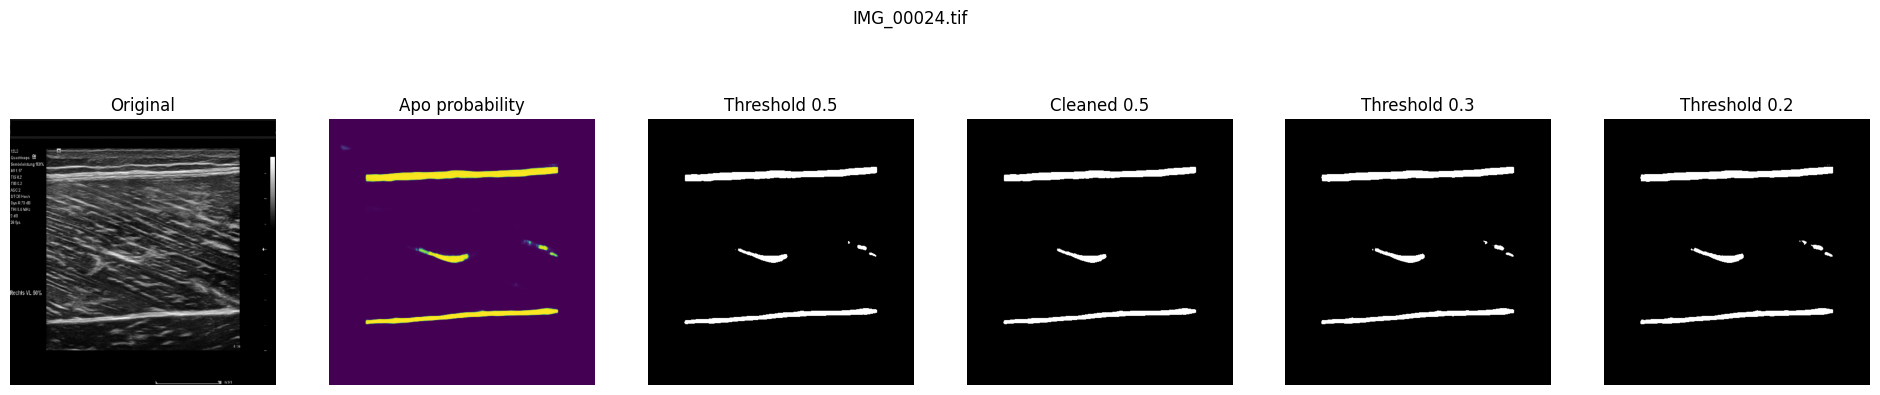

In [ ]:
idx = 23

img_path = test_images[idx]
row = test_df.iloc[idx]

img = load_img(img_path, color_mode="grayscale", target_size=(IMG_SIZE, IMG_SIZE))
img = img_to_array(img).astype("float32") / 255.0
img_batch = np.expand_dims(img, axis=0)

apo_pred = apo_model_dice.predict(img_batch, verbose=0)
apo_prob = apo_pred[0, :, :, 0]

apo_mask_05 = apo_prob > 0.5
apo_mask_03 = apo_prob > 0.3
apo_mask_02 = apo_prob > 0.2

apo_clean_05 = clean_mask(apo_mask_05, min_size=300, hole_size=300)
apo_clean_03 = clean_mask(apo_mask_03, min_size=100, hole_size=100)

fig, ax = plt.subplots(1, 6, figsize=(24, 5))

ax[0].imshow(img.squeeze(), cmap="gray")
ax[0].set_title("Original")

ax[1].imshow(apo_prob, cmap="viridis")
ax[1].set_title("Apo probability")

ax[2].imshow(apo_mask_05, cmap="gray")
ax[2].set_title("Threshold 0.5")

ax[3].imshow(apo_clean_05, cmap="gray")
ax[3].set_title("Cleaned 0.5")

ax[4].imshow(apo_mask_03, cmap="gray")
ax[4].set_title("Threshold 0.3")

ax[5].imshow(apo_mask_02, cmap="gray")
ax[5].set_title("Threshold 0.2")

for a in ax:
    a.axis("off")

plt.suptitle(row["image_id"])
plt.show()

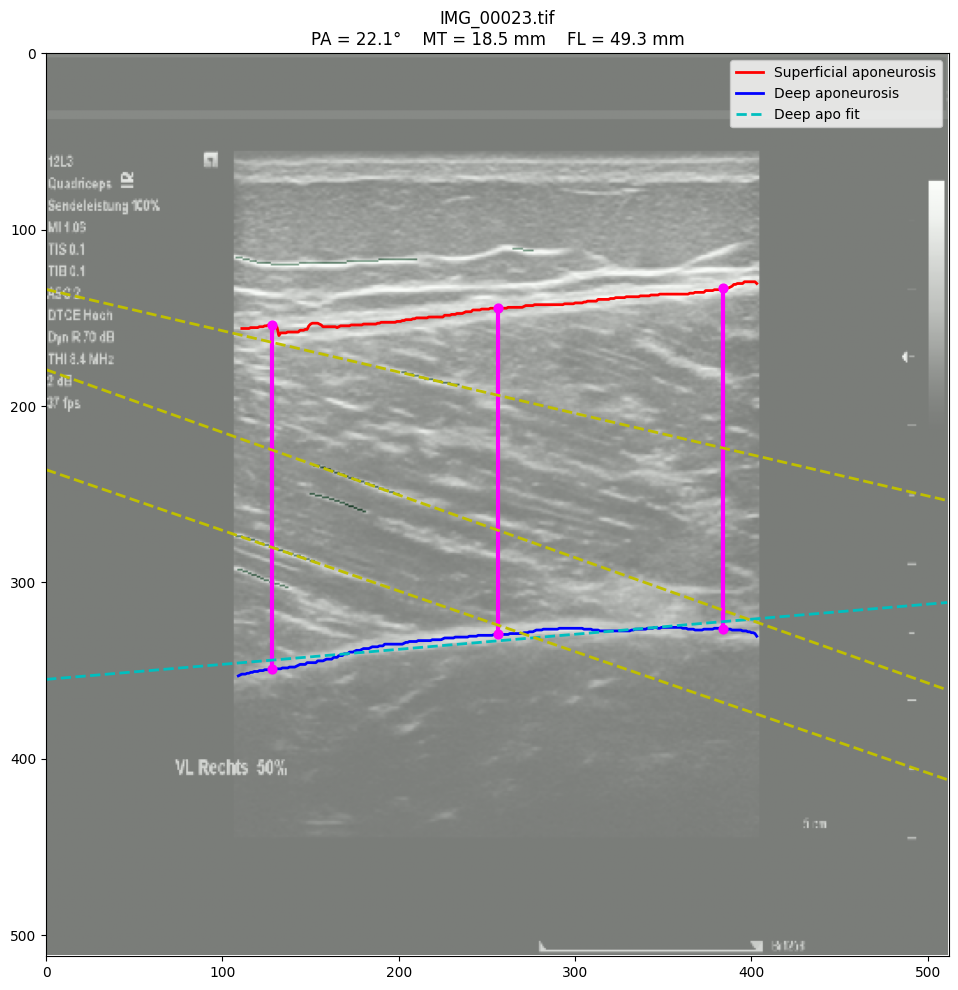

('IMG_00023.tif', 22.120066012317324, 49.25259406572515, 18.546001599274767)

In [ ]:
idx = 22
predict_image(idx, show=True)